# Daily Univariate Matrix Profile Motif Discovery

This notebook creates a reproducible **daily-resolution** motif discovery baseline for the thesis. It uses Matrix Profile discovery on one configurable daily signal, defaulting to `log_return`, and keeps the daily workflow explicit so that later regime-conditioned extensions can reuse the same daily feature construction logic.

## Why daily analysis is methodologically different from minute analysis

Daily bars suppress microstructure noise, intraday seasonality, and very short-lived volatility bursts that dominate minute-level distance calculations. That makes daily motif discovery better suited to testing whether medium-horizon structures recur across market regimes, while still preserving nonstationary behavior in returns, volatility, range, and volume.

## Setup

The notebook assumes the repository dependencies have already been installed from the project root:

```bash
pip install -r requirements.txt
```

The shared helper functions are imported from `src.analysis.daily_motif_notebook_utils`, which centralizes data resolution, daily aggregation, feature engineering, motif extraction, and plotting.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stumpy
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def notebook_resolve_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing both src/ and data/.")


PROJECT_ROOT = notebook_resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.analysis.daily_motif_notebook_utils import (
    apply_run_mode,
    build_daily_ohlcv,
    compute_daily_features,
    extract_top_non_overlapping_discords,
    extract_top_non_overlapping_motifs,
    infer_timestamp_frequency,
    plot_discord_windows,
    plot_matrix_profile_with_motifs,
    plot_motif_pair_comparison,
    plot_multichannel_motif_comparison,
    plot_multichannel_overview,
    plot_multichannel_windows,
    plot_normalized_motif_overlay,
    plot_series_over_time,
    plot_univariate_windows,
    prepare_multivariate_panel,
    prepare_univariate_series,
    read_market_data,
    resolve_input_data,
    summarize_motifs,
)

In [3]:
RUN_MODE = "quick_test"  # Switch to "full_run" for the full available daily history.
ASSET_SYMBOL = "BTCUSDT"
FALLBACK_SYMBOLS = ["ETHUSDT"]
TARGET_COLUMN = "log_return"
WINDOW_DAYS = 30
VOLATILITY_WINDOW = 21
VOLUME_ZSCORE_WINDOW = 21
QUICK_TEST_DAYS = 540

TOP_K_MOTIFS = 5 if RUN_MODE == "full_run" else 3
TOP_K_DISCORDS = 5 if RUN_MODE == "full_run" else 2
PAIR_PLOTS_TO_RENDER = 3 if RUN_MODE == "full_run" else 2

print(f"Project root: {PROJECT_ROOT}")
print(f"RUN_MODE: {RUN_MODE}")
print(f"Requested symbol: {ASSET_SYMBOL}")
print(f"Target signal: {TARGET_COLUMN}")
print(f"Window length (days): {WINDOW_DAYS}")

Project root: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis
RUN_MODE: quick_test
Requested symbol: BTCUSDT
Target signal: log_return
Window length (days): 30


## Resolve input data and build the daily feature frame

The notebook first resolves the best available BTCUSDT dataset. If a daily dataset does not already exist, the selected intraday OHLCV data is aggregated to daily bars using the thesis-standard rules:

- `open = first`
- `high = max`
- `low = min`
- `close = last`
- `volume = sum`

Daily features are recomputed from the aggregated daily OHLCV table so that the downstream motif discovery step never mixes daily and intraday feature definitions.

In [4]:
source_info = resolve_input_data(
    PROJECT_ROOT,
    preferred_symbol=ASSET_SYMBOL,
    fallback_symbols=FALLBACK_SYMBOLS,
)
source_frame = read_market_data(source_info["path"])
frequency_info = infer_timestamp_frequency(source_frame)
daily_ohlcv = build_daily_ohlcv(source_frame)
daily_feature_frame = compute_daily_features(
    daily_ohlcv,
    volatility_window=VOLATILITY_WINDOW,
    volume_window=VOLUME_ZSCORE_WINDOW,
)
analysis_feature_frame = apply_run_mode(
    daily_feature_frame,
    run_mode=RUN_MODE,
    quick_test_days=QUICK_TEST_DAYS,
)

available_columns = [
    column
    for column in [
        "close",
        TARGET_COLUMN,
        "log_return",
        "pct_return",
        "hl_range",
        "rolling_volatility",
        "volume",
        "volume_zscore",
    ]
    if column in analysis_feature_frame.columns
]

print(f"Resolved symbol: {source_info['symbol']}")
print(f"Selected source path: {source_info['path'].relative_to(PROJECT_ROOT)}")
print(f"Candidate paths considered: {len(source_info['candidate_paths'])}")
print(f"Median observed source interval: {frequency_info['median_delta']}")
print(
    "Daily aggregation rule: "
    "open=first, high=max, low=min, close=last, volume=sum"
)
print(f"Source rows: {len(source_frame):,}")
print(f"Daily rows before run-mode slicing: {len(daily_feature_frame):,}")
print(f"Daily rows after run-mode slicing: {len(analysis_feature_frame):,}")
print(
    f"Date range after run-mode slicing: "
    f"{analysis_feature_frame['timestamp'].min()} -> {analysis_feature_frame['timestamp'].max()}"
)
print(f"Available analysis columns: {available_columns}")

display(pd.DataFrame(source_info["search_log"]))
display(analysis_feature_frame.loc[:, ["timestamp", *available_columns]].head())

Resolved symbol: BTCUSDT
Selected source path: data\processed\crypto\1min\BTCUSDT_1m_processed.parquet
Candidate paths considered: 2
Median observed source interval: 0 days 00:01:00
Daily aggregation rule: open=first, high=max, low=min, close=last, volume=sum
Source rows: 4,502,648
Daily rows before run-mode slicing: 3,133
Daily rows after run-mode slicing: 540
Date range after run-mode slicing: 2024-09-22 00:00:00+00:00 -> 2026-03-15 00:00:00+00:00
Available analysis columns: ['close', 'log_return', 'log_return', 'pct_return', 'hl_range', 'rolling_volatility', 'volume', 'volume_zscore']


,symbol,candidate_count,top_candidates
0,BTCUSDT,2,[data\processed\crypto\1min\BTCUSDT_1m_process...


,timestamp,close,log_return,log_return,pct_return,hl_range,rolling_volatility,volume,volume_zscore
0,2024-09-22 00:00:00+00:00,"63,578.760000",0.003621,0.003621,0.003628,0.025827,0.022681,"14,242.198920",-1.127635
1,2024-09-23 00:00:00+00:00,"63,339.990000",-0.003763,-0.003763,-0.003755,0.034846,0.021913,"24,078.052870",-0.206585
2,2024-09-24 00:00:00+00:00,"64,262.700000",0.014462,0.014462,0.014568,0.030936,0.020798,"23,185.047590",-0.292594
3,2024-09-25 00:00:00+00:00,"63,152.010000",-0.017435,-0.017435,-0.017284,0.029626,0.021363,"17,813.111680",-0.724656
4,2024-09-26 00:00:00+00:00,"65,173.990000",0.031516,0.031516,0.032018,0.048624,0.020536,"28,373.305930",0.276019


## Daily overview plots

The first plot shows the daily close series for context. The second plot isolates the configured univariate signal that will be passed to STUMPY.

(<Figure size 1680x504 with 1 Axes>,
 <Axes: title={'center': 'BTCUSDT daily log_return'}, xlabel='Date', ylabel='log_return'>)

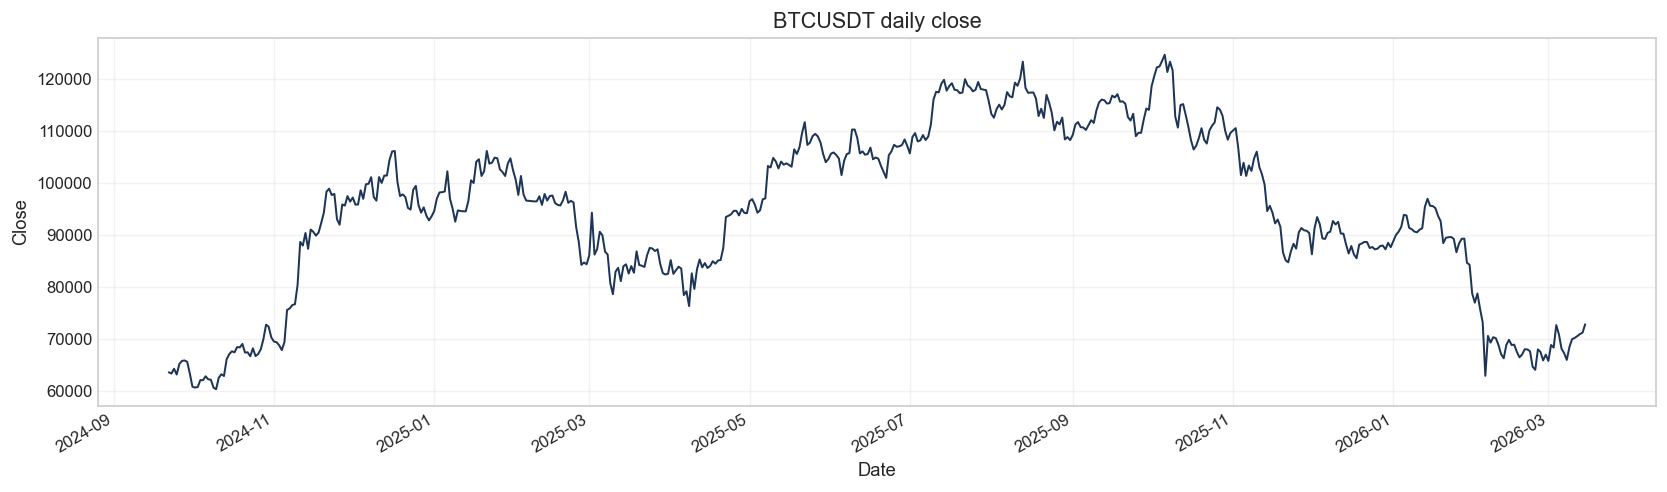

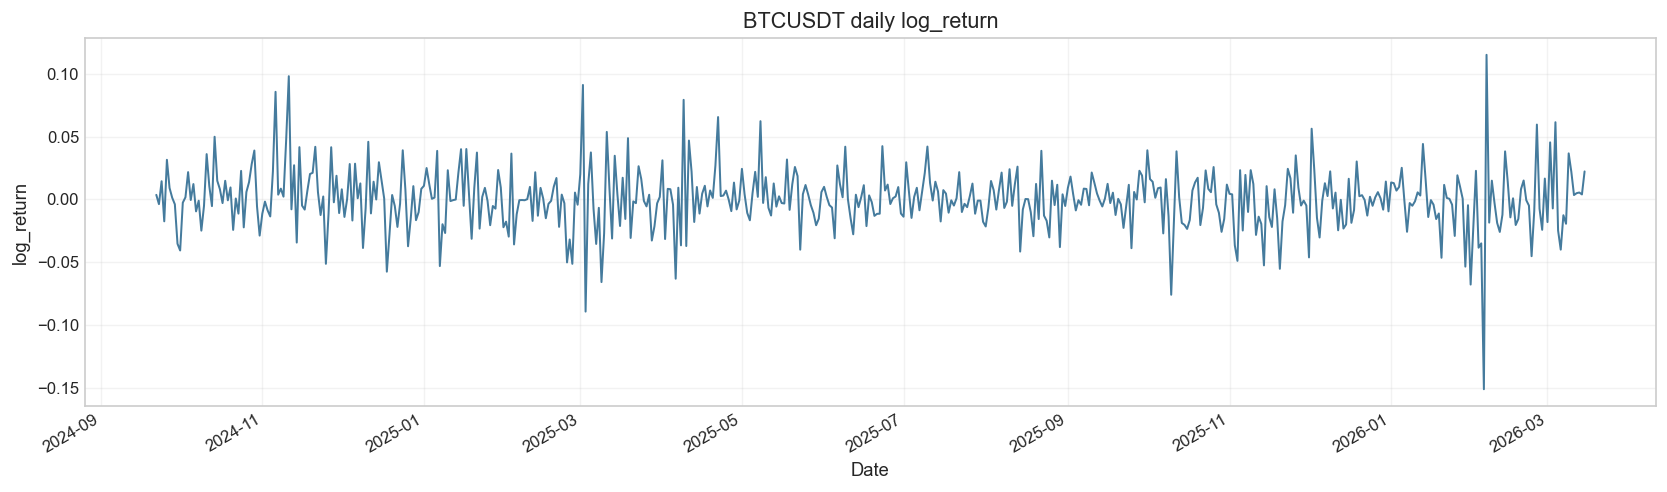

In [5]:
plot_series_over_time(
    analysis_feature_frame,
    value_column="close",
    title=f"{source_info['symbol']} daily close",
    ylabel="Close",
)
plot_series_over_time(
    analysis_feature_frame,
    value_column=TARGET_COLUMN,
    title=f"{source_info['symbol']} daily {TARGET_COLUMN}",
    ylabel=TARGET_COLUMN,
    color="#457b9d",
)

## Compute the daily matrix profile

The notebook uses a self-join `stumpy.stump` computation with the library-default exclusion zone. The ranking stage then keeps only **non-overlapping** motifs and discords so the summary emphasizes genuinely distinct subsequences rather than near-duplicates.

In [6]:
analysis_frame = prepare_univariate_series(analysis_feature_frame, target_column=TARGET_COLUMN)
if len(analysis_frame) <= WINDOW_DAYS:
    raise ValueError(
        f"Need more than WINDOW_DAYS={WINDOW_DAYS} clean daily rows for motif discovery. "
        f"Received {len(analysis_frame)} rows."
    )

series_values = analysis_frame[TARGET_COLUMN].to_numpy(dtype=np.float64)
matrix_profile = stumpy.stump(series_values, m=WINDOW_DAYS)
profile = np.asarray(matrix_profile[:, 0], dtype=np.float64)
indices = np.asarray(matrix_profile[:, 1], dtype=np.int64)

motif_df = extract_top_non_overlapping_motifs(
    profile,
    indices,
    analysis_frame["timestamp"],
    window_size=WINDOW_DAYS,
    top_k=TOP_K_MOTIFS,
)
discord_df = extract_top_non_overlapping_discords(
    profile,
    analysis_frame["timestamp"],
    window_size=WINDOW_DAYS,
    top_k=TOP_K_DISCORDS,
)
motif_summary = summarize_motifs(motif_df)

if motif_df.empty:
    raise ValueError("No non-overlapping daily motifs were found for the configured signal and window length.")

print("STUMPY self-join exclusion zone: library default used (no manual override).")
print(f"Rows entering STUMPY: {len(analysis_frame):,}")
print(f"Subsequence count: {len(profile):,}")
print(f"Selected motifs: {len(motif_df)}")
print(f"Selected discords: {len(discord_df)}")

display(motif_summary)
display(discord_df.head())

STUMPY self-join exclusion zone: library default used (no manual override).
Rows entering STUMPY: 540
Subsequence count: 511
Selected motifs: 3
Selected discords: 2


,rank,motif_start,motif_end,nearest_neighbor_start,nearest_neighbor_end,profile_value,window_size
0,1,2025-10-05 00:00:00+00:00,2025-11-03 00:00:00+00:00,2025-03-04 00:00:00+00:00,2025-04-02 00:00:00+00:00,4.569327,30
1,2,2024-12-18 00:00:00+00:00,2025-01-16 00:00:00+00:00,2024-10-01 00:00:00+00:00,2024-10-30 00:00:00+00:00,4.670468,30
2,3,2025-06-07 00:00:00+00:00,2025-07-06 00:00:00+00:00,2025-11-07 00:00:00+00:00,2025-12-06 00:00:00+00:00,4.770653,30


,discord_rank,discord_index,discord_score,discord_start,discord_end,window_size
0,1,234,5.965697,2025-05-14 00:00:00+00:00,2025-06-12 00:00:00+00:00,30
1,2,448,5.955903,2025-12-14 00:00:00+00:00,2026-01-12 00:00:00+00:00,30


(<Figure size 1680x528 with 1 Axes>,
 <Axes: title={'center': 'BTCUSDT daily matrix profile on log_return'}, xlabel='Subsequence start date', ylabel='Profile value'>)

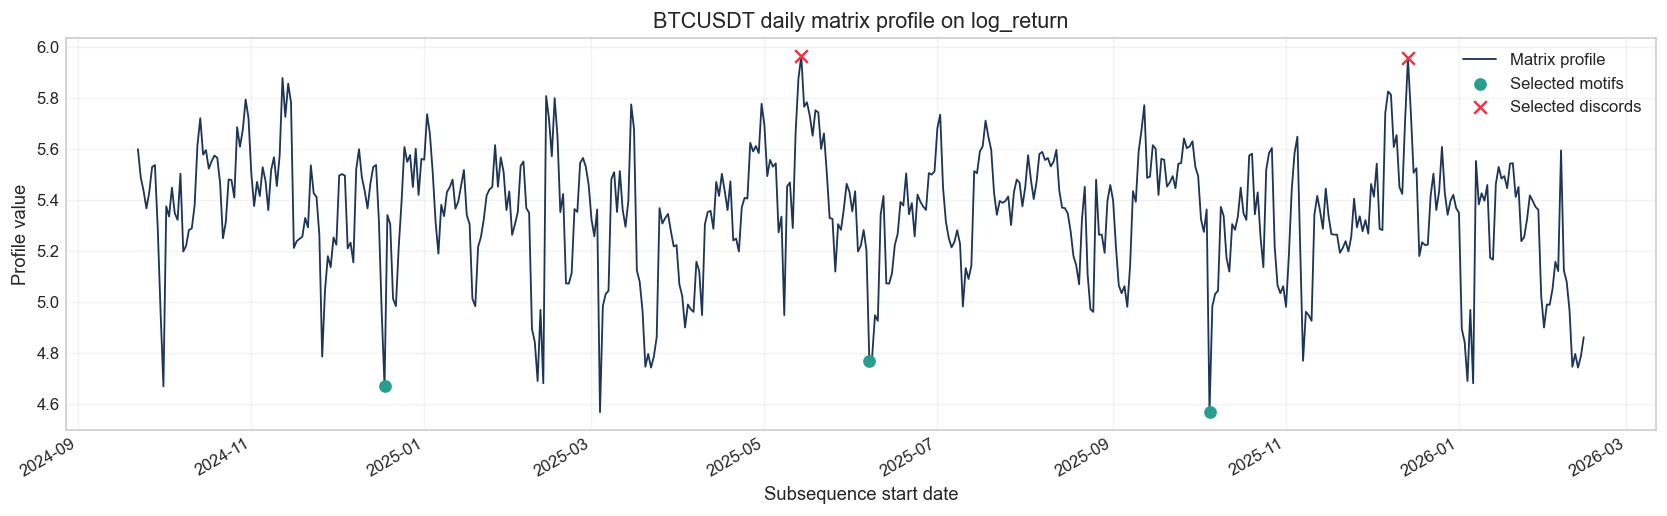

In [7]:
plot_matrix_profile_with_motifs(
    profile,
    analysis_frame["timestamp"],
    motif_df=motif_df,
    discord_df=discord_df,
    title=f"{source_info['symbol']} daily matrix profile on {TARGET_COLUMN}",
)

(<Figure size 1680x552 with 1 Axes>,
 <Axes: title={'center': 'log_return with highlighted motif windows'}, xlabel='Date', ylabel='log_return'>)

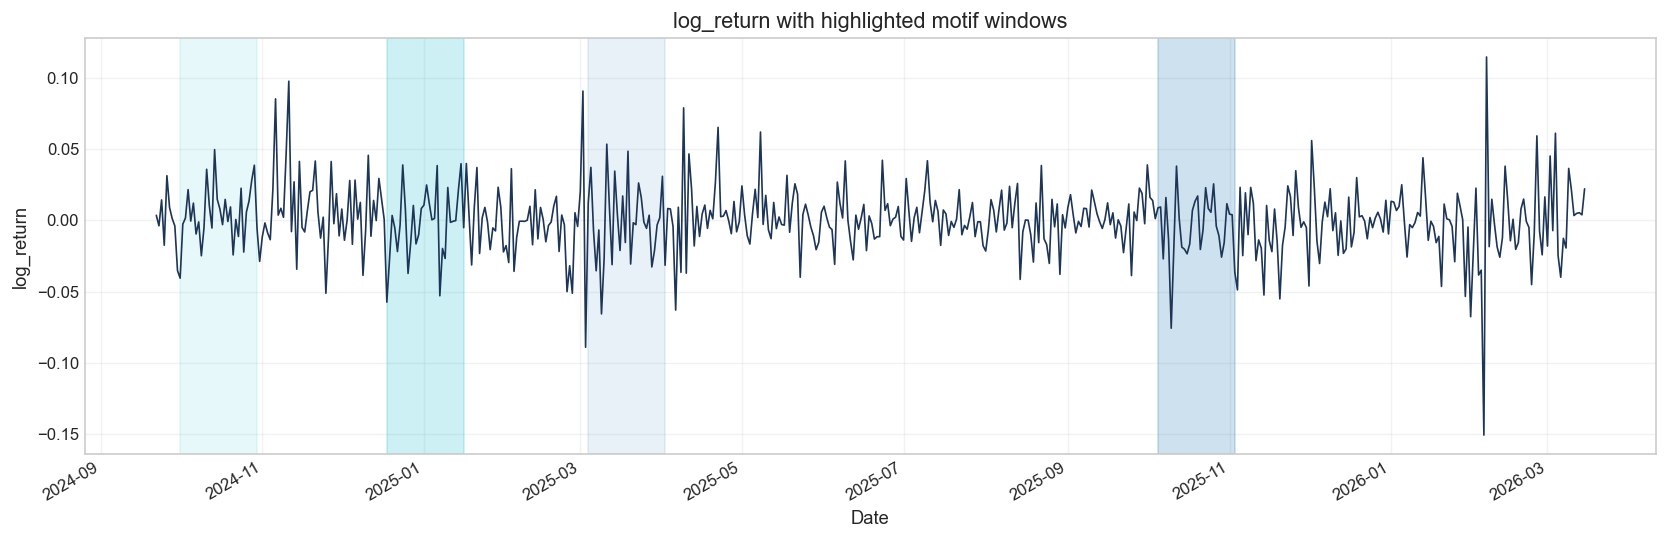

In [8]:
plot_univariate_windows(
    analysis_frame,
    value_column=TARGET_COLUMN,
    motif_df=motif_df,
    max_motifs=PAIR_PLOTS_TO_RENDER,
)

## Motif-pair inspection

Each motif is inspected twice:

- on the original daily scale, to preserve the observed values and dates;
- on a within-window standardized scale, to compare shape similarity independently of level.

Motif rank 1 | profile=4.5693 | 2025-10-05 -> 2025-11-03
Motif rank 2 | profile=4.6705 | 2024-12-18 -> 2025-01-16


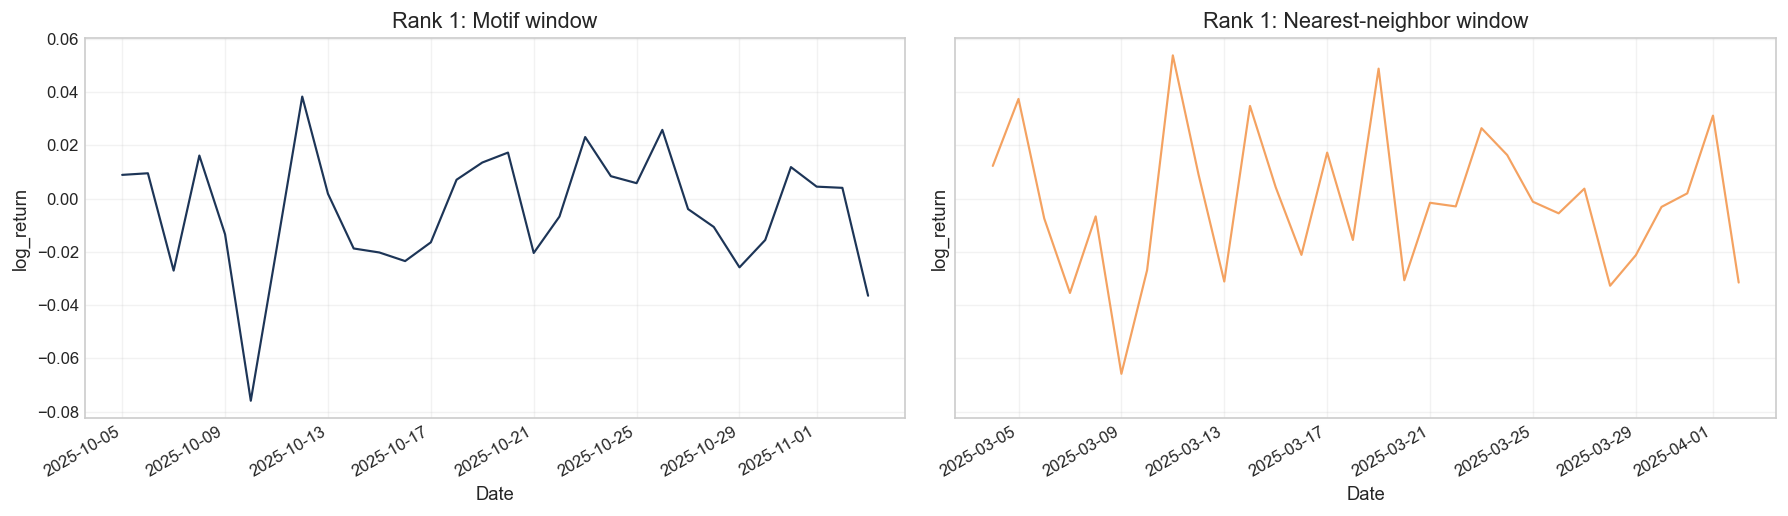

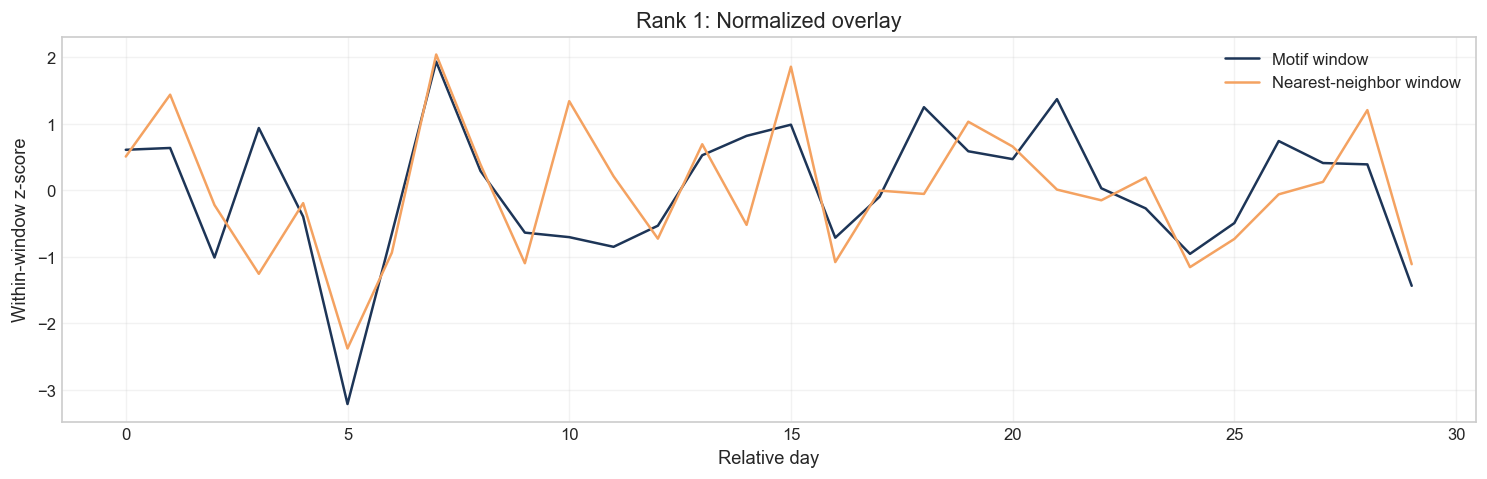

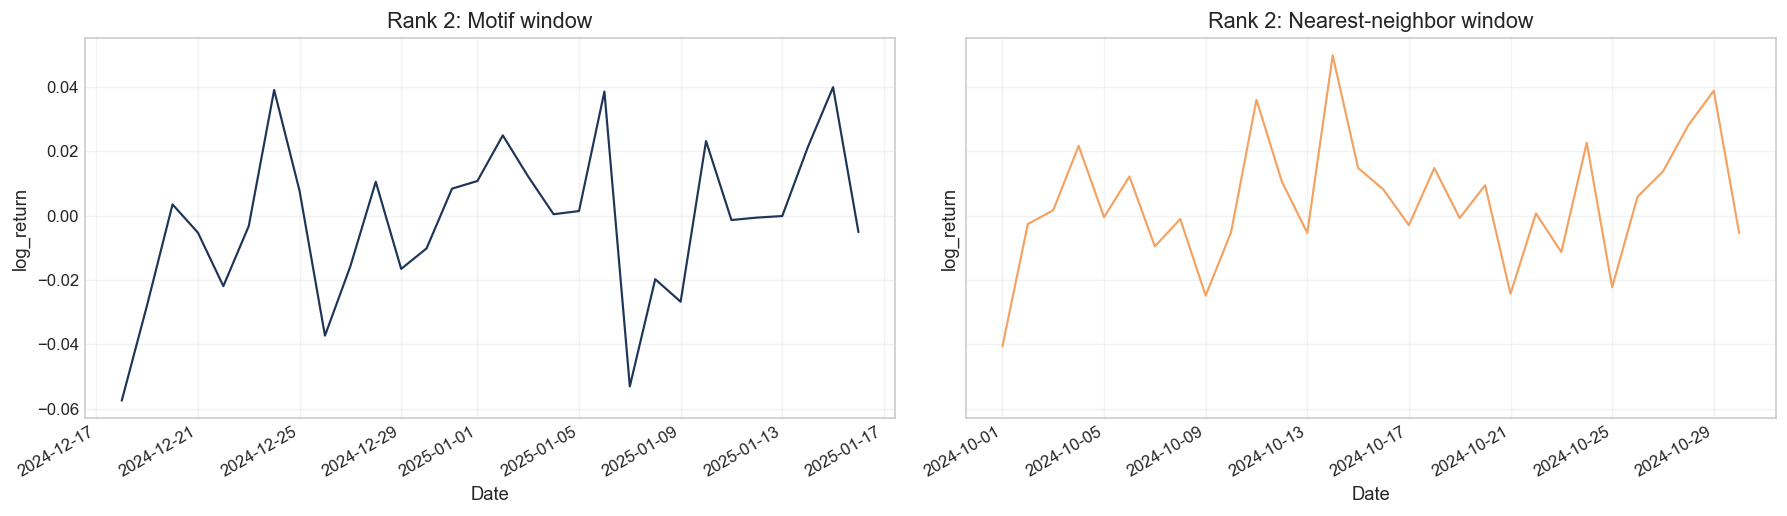

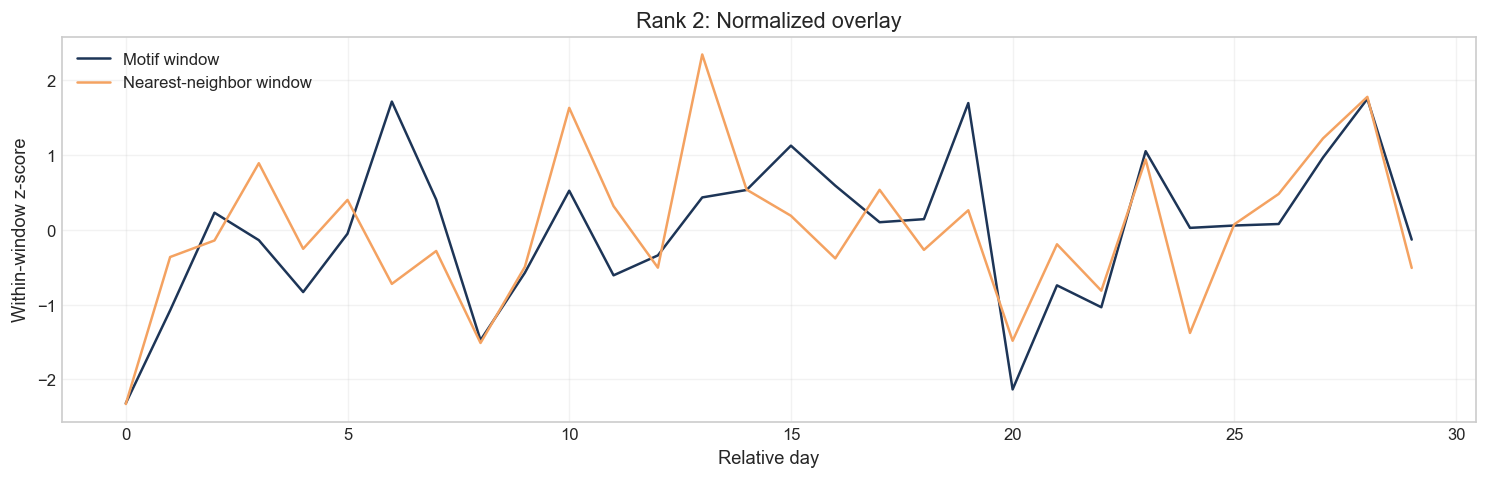

In [9]:
for _, motif_row in motif_df.head(PAIR_PLOTS_TO_RENDER).iterrows():
    print(
        f"Motif rank {int(motif_row['rank'])} | "
        f"profile={motif_row['profile_value']:.4f} | "
        f"{motif_row['motif_start'].date()} -> {motif_row['motif_end'].date()}"
    )
    plot_motif_pair_comparison(
        analysis_frame,
        value_column=TARGET_COLUMN,
        motif_row=motif_row,
        window_size=WINDOW_DAYS,
        title_prefix=f"Rank {int(motif_row['rank'])}: ",
    )
    plot_normalized_motif_overlay(
        analysis_frame,
        value_column=TARGET_COLUMN,
        motif_row=motif_row,
        window_size=WINDOW_DAYS,
        title_prefix=f"Rank {int(motif_row['rank'])}: ",
    )

## Optional discord inspection

Discords are the most unusual daily subsequences under the same Matrix Profile distance definition. They are useful for checking whether structural breaks, shocks, or isolated volatility bursts are dominating the search space.

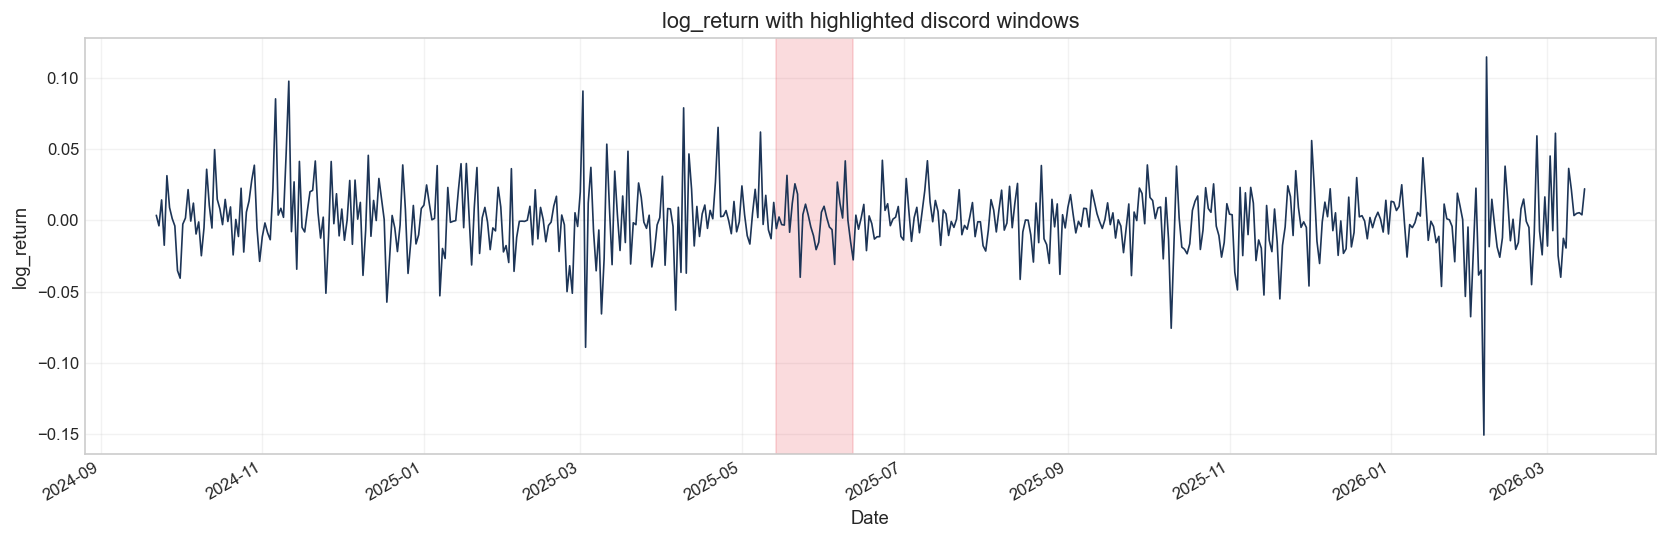

In [10]:
if not discord_df.empty:
    plot_discord_windows(
        analysis_frame,
        value_column=TARGET_COLUMN,
        discord_df=discord_df,
        max_discords=min(1, len(discord_df)),
    )

## Interpretation for the thesis

A low-distance daily motif indicates that the selected daily signal revisited a similar path over the configured horizon. In this notebook, that statement is intentionally univariate: it says the chosen signal recurred, not yet that the full market state recurred. That distinction matters for the thesis because the next notebook moves to a multivariate definition of recurrence, which is a closer match to regime-conditioned motif discovery.

In [11]:
motif_summary

,rank,motif_start,motif_end,nearest_neighbor_start,nearest_neighbor_end,profile_value,window_size
0,1,2025-10-05 00:00:00+00:00,2025-11-03 00:00:00+00:00,2025-03-04 00:00:00+00:00,2025-04-02 00:00:00+00:00,4.569327,30
1,2,2024-12-18 00:00:00+00:00,2025-01-16 00:00:00+00:00,2024-10-01 00:00:00+00:00,2024-10-30 00:00:00+00:00,4.670468,30
2,3,2025-06-07 00:00:00+00:00,2025-07-06 00:00:00+00:00,2025-11-07 00:00:00+00:00,2025-12-06 00:00:00+00:00,4.770653,30
